In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
df=pd.read_csv('Maha_OC.csv')
df.head()

/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_3075/375108006.py:1: DtypeWarning: Columns (0: address, 1: osm_positive_class) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Maha_OC.csv')


,lat_key,lon_key,sample_date_clean,fid,tehsil,latitude,longitude,CLIMATE_VALUE,CLIMATE_SUBCLASS,CLIMATE_CLASS,...,S1_VH_Contrast,S1_VH_Dissimilarity,S1_VH_Homogeneity,S1_VH_ASM,S1_VH_Energy,S1_VH_MaxProbability,S1_VH_Entropy,S1_VH_GLCM_Mean,S1_VH_GLCM_Variance,S1_VH_GLCM_Correlation
0,15.709677,74.047631,17-02-2025,48980.0,NaN,15.709677,74.047631,2.0,Am,Tropical,...,0.000029,0.004043,0.999971,0.699068,0.999988,0.995973,-4.731746,0.022191,0.000029,0.424396
1,15.709731,74.048897,17-02-2025,48981.0,NaN,15.709731,74.048897,2.0,Am,Tropical,...,0.000017,0.002687,0.999983,0.636399,0.999990,0.997320,-4.856527,0.016932,0.000098,0.181971
2,15.711065,74.047657,17-02-2025,48982.0,NaN,15.711065,74.047657,2.0,Am,Tropical,...,0.000062,0.004647,0.999938,0.606309,0.999960,0.995374,-4.144549,0.013338,0.000111,0.318890
3,15.804995,73.733783,31-03-2024,48839.5,NaN,15.804995,73.733783,2.0,Am,Tropical,...,0.000002,0.001194,0.999998,0.774612,0.999999,0.998807,-6.255501,0.007464,0.000004,0.314625
4,15.805012,73.734112,31-03-2024,48835.0,NaN,15.805012,73.734112,2.0,Am,Tropical,...,0.000006,0.001653,0.999994,0.648962,0.999997,0.998350,-5.404119,0.007534,0.000008,1.216725


In [80]:
print(df.shape)

(29942, 191)


In [81]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 29942 entries, 0 to 29941
Columns: 191 entries, lat_key to S1_VH_GLCM_Correlation
dtypes: bool(24), float64(132), int64(7), str(28)
memory usage: 38.8 MB
None


In [82]:
print(df.describe())

            lat_key       lon_key           fid  tehsil      latitude  \
count  29942.000000  29942.000000  29942.000000     0.0  29942.000000   
mean      19.462623     76.013779  28179.301416     NaN     19.462623   
std        1.336650      2.096483  15998.756037     NaN      1.336650   
min       15.709677     72.690910      2.000000     NaN     15.709677   
25%       18.377480     74.327849  14130.250000     NaN     18.377480   
50%       19.693437     75.549651  28532.000000     NaN     19.693437   
75%       20.564832     77.171010  41761.750000     NaN     20.564832   
max       21.923125     80.651655  55784.000000     NaN     21.923125   

          longitude  CLIMATE_VALUE     elevation     slope_deg    aspect_deg  \
count  29942.000000   29939.000000  29942.000000  29942.000000  29942.000000   
mean      76.013779       4.098400    424.418776      2.857658    161.501770   
std        2.096483       1.588149    204.063803      2.206116    106.444379   
min       72.690910   

#### Missing Value Analysis

In [83]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing>0])

DISTRICT_L            29942
Texture               29942
Survey_N_1            29942
MANDAL                29942
tehsil                29942
BLOCK                 29942
STATE_LGD             29942
HSG                   29942
Erosion               29942
LIC                   29942
Category              29942
Soil_Depth            29942
Slope                 29942
LCC                   29942
address               29915
osm_positive_class    29507
OC_group_std          25332
SOIL_SUBCLASS            47
DOMSOI                   47
SOIL_TYPE                47
Red_Blue_Ratio           35
K                         5
P                         5
N                         5
Red_Green_Ratio           4
RI                        4
CLIMATE_CLASS             3
CLIMATE_SUBCLASS          3
CLIMATE_VALUE             3
NDVI_calc                 1
MCARI                     1
NDWI_Green_NIR            1
GNDVI                     1
RVI                       1
MSI                       1
CI                  

In [84]:
missing_percent = (df.isnull().sum()/len(df))*100
print(missing_percent.sort_values(ascending=False))

DISTRICT_L                100.0
Texture                   100.0
Survey_N_1                100.0
MANDAL                    100.0
tehsil                    100.0
                          ...  
state                       0.0
district                    0.0
village                     0.0
date                        0.0
S1_VH_GLCM_Correlation      0.0
Length: 191, dtype: float64


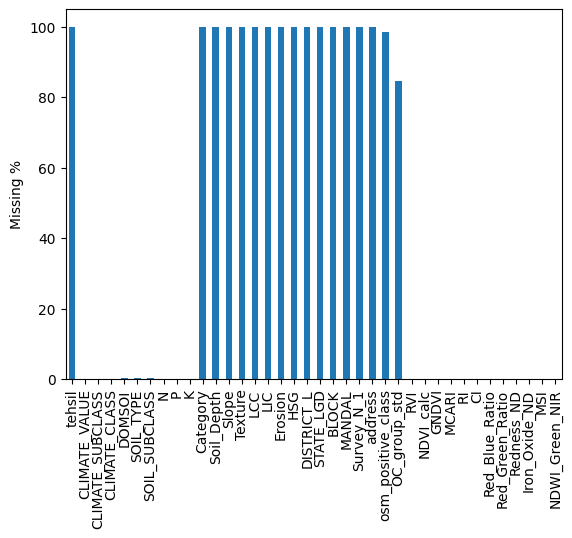

In [85]:
import matplotlib.pyplot as plt

missing_percent[missing_percent>0].plot(kind='bar')
plt.ylabel("Missing %")
plt.show()

In [86]:
df = df.dropna(axis=1,how='all')

In [87]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

address               29915
osm_positive_class    29507
OC_group_std          25332
DOMSOI                   47
SOIL_SUBCLASS            47
SOIL_TYPE                47
Red_Blue_Ratio           35
K                         5
N                         5
P                         5
Red_Green_Ratio           4
RI                        4
CLIMATE_CLASS             3
CLIMATE_VALUE             3
CLIMATE_SUBCLASS          3
GNDVI                     1
RVI                       1
NDVI_calc                 1
MSI                       1
CI                        1
dtype: int64


In [89]:
missing_cols=["address","osm_positive_class","OC_group_std"];
df.drop(columns=missing_cols,inplace=True,errors='ignore')

In [90]:
cat_fill = [
    'DOMSOI',
    'SOIL_SUBCLASS',
    'SOIL_TYPE',
    'CLIMATE_CLASS',
    'CLIMATE_VALUE',
    'CLIMATE_SUBCLASS'
]

num_fill = [
    'Red_Blue_Ratio',
    'K',
    'N',
    'P',
    'Red_Green_Ratio',
    'RI',
    'GNDVI',
    'RVI',
    'NDVI_calc',
    'MSI',
    'CI'
]

In [93]:
for col in cat_fill:
    
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

for col in num_fill:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

In [94]:
print(
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Redness_ND                     1
Iron_Oxide_ND                  1
MCARI                          1
NDWI_Green_NIR                 1
lat_key                        0
GNDVI                          0
OC_group_range                 0
duplicate_OC_conflict_class    0
OC_bin                         0
OC_log1p                       0
RVI                            0
NDVI_calc                      0
SAVI                           0
NDI45                          0
OC_group_max                   0
IRECI                          0
BI_Escadafal                   0
BI2_Escadafal                  0
BI_VIS                         0
BI_SWIR                        0
dtype: int64


In [95]:
remaining_num = [
    'Redness_ND',
    'Iron_Oxide_ND',
    'MCARI',
    'NDWI_Green_NIR'
]

for col in remaining_num:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

In [96]:
missing = df.isnull().sum()

print(
    missing[
        missing > 0
    ]
)

Series([], dtype: int64)


In [97]:
df.shape

(29942, 174)

#### Categorize the columns

In [98]:
print(df.dtypes)

lat_key                   float64
lon_key                   float64
sample_date_clean             str
fid                       float64
latitude                  float64
                           ...   
S1_VH_MaxProbability      float64
S1_VH_Entropy             float64
S1_VH_GLCM_Mean           float64
S1_VH_GLCM_Variance       float64
S1_VH_GLCM_Correlation    float64
Length: 174, dtype: object


In [99]:
# Soil related columns
soil_cols = [
    c for c in df.columns
    if any(x.lower() in c.lower() for x in [
        'soil','oc','ph','texture',
        'erosion','depth','category',
        'n','p','k','zn','fe',
        'mn','cu','b','ec',
        'hsg','lcc','lic'
    ])
]

# Terrain / topography columns
terrain_cols = [
    c for c in df.columns
    if any(x.lower() in c.lower() for x in [
        'elev','slope','aspect',
        'twi','flow','curvature',
        'tpi','spi','ls_factor'
    ])
]

# Spectral indices
spectral_cols = [
    c for c in df.columns
    if any(x.lower() in c.lower() for x in [
        'nd','gndvi','savi',
        'mndwi','ratio','bi_',
        'ri','ci','msi',
        'ireci','mcari'
    ])
]

# Radar features
radar_cols = [
    c for c in df.columns
    if c.startswith('S1_') or c == 'RVI'
]

# Climate columns
climate_cols = [
    c for c in df.columns
    if any(x.lower() in c.lower() for x in [
        'climate','rain','r_factor'
    ])
]

# Spatial columns
spatial_cols = [
    c for c in df.columns
    if any(x.lower() in c.lower() for x in [
        'lat','lon','district',
        'state','village',
        'block','mandal',
        'tehsil'
    ])
]

# Quality control columns
qc_cols = [
    c for c in df.columns
    if any(x.lower() in c.lower() for x in [
        'reject','review',
        'filter','osm',
        'cloud','water',
        'building','qc'
    ])
]

In [100]:
print("Soil:", len(soil_cols))
print("Terrain:", len(terrain_cols))
print("Spectral:", len(spectral_cols))
print("Radar:", len(radar_cols))
print("Climate:", len(climate_cols))
print("Spatial:", len(spatial_cols))
print("QC:", len(qc_cols))

Soil: 133
Terrain: 18
Spectral: 43
Radar: 28
Climate: 5
Spatial: 9
QC: 24


Missing Values by category :

In [101]:
for name, cols in {
    "soil": soil_cols,
    "terrain": terrain_cols,
    "spectral": spectral_cols,
    "radar": radar_cols
}.items():

    print("\n",name)

    missing = df[cols].isnull().mean()*100

    print(
        missing[missing>0]
        .sort_values(ascending=False)
    )


 soil
Series([], dtype: float64)

 terrain
Series([], dtype: float64)

 spectral
Series([], dtype: float64)

 radar
Series([], dtype: float64)


#### Distribution Analysis

In [102]:
# soil_numeric = df[soil_cols].select_dtypes(include=['int64','float64']).columns

# print("Numeric soil columns:")
# print(soil_numeric)

# batch_size = 8   
# for i in range(0, len(soil_numeric), batch_size):
#     subset = soil_numeric[i:i+batch_size]
#     df[subset].hist(figsize=(15,10),bins=30)
#     plt.suptitle(f"Soil Variables Batch {i//batch_size + 1}",fontsize=14)    
#     plt.tight_layout()
#     plt.show()

In [103]:
# import math

# terrain_numeric = df[terrain_cols].select_dtypes(include=['int64','float64']).columns
# n_cols = 3
# n_rows = math.ceil(len(terrain_numeric) / n_cols)
# df[terrain_numeric].hist( figsize=(20,5*n_rows), bins=30,layout=(n_rows,n_cols))
# plt.tight_layout()
# plt.show()

In [104]:
df[soil_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
lat_key,29942.0,19.462623,1.336650,1.570968e+01,18.377480,19.693437,20.564832,21.923125
lon_key,29942.0,76.013779,2.096483,7.269091e+01,74.327849,75.549651,77.171010,80.651655
longitude,29942.0,76.013779,2.096483,7.269091e+01,74.327849,75.549651,77.171010,80.651655
elevation,29942.0,424.418776,204.063803,-2.000000e+00,253.000000,445.000000,586.000000,1304.000000
slope_deg,29942.0,2.857658,2.206116,0.000000e+00,1.000000,2.000000,4.000000,36.000000
...,...,...,...,...,...,...,...,...
S1_VH_MaxProbability,29942.0,0.997261,0.003612,7.799551e-01,0.996776,0.997873,0.998563,0.999985
S1_VH_Entropy,29942.0,-5.274066,0.724358,-8.507796e+00,-5.792377,-5.300297,-4.802150,0.067801
S1_VH_GLCM_Mean,29942.0,0.012870,0.009076,3.171785e-03,0.008220,0.011259,0.015332,0.501361
S1_VH_GLCM_Variance,29942.0,0.000131,0.004270,3.290000e-09,0.000008,0.000019,0.000046,0.512857


In [105]:
df[terrain_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
elevation,29942.0,424.418776,204.063803,-2.000000,253.000000,4.450000e+02,586.000000,1304.000000
slope_deg,29942.0,2.857658,2.206116,0.000000,1.000000,2.000000e+00,4.000000,36.000000
aspect_deg,29942.0,161.501770,106.444379,0.000000,70.250000,1.600000e+02,259.000000,356.000000
aspect_sin,29942.0,0.001983,0.694805,-1.000000,-0.731354,0.000000e+00,0.731354,1.000000
aspect_cos,29942.0,0.029507,0.718613,-1.000000,-0.681998,6.123234e-17,0.694658,1.000000
TWI,29942.0,3.433199,1.063298,0.332847,2.937751,3.335655e+00,4.002190,15.762725
flow_acc,29942.0,0.928114,41.669528,0.007943,0.010781,2.075011e-02,0.063366,7008.132000
log_flow_acc,29942.0,0.148690,0.448848,0.007912,0.010723,2.053776e-02,0.061440,8.854969
profile_curvature,29942.0,-10.545941,1040.438836,-23000.000000,-93.619320,0.000000e+00,84.822250,20000.000000
plan_curvature,29942.0,-0.008896,0.624649,-20.736668,-0.139683,0.000000e+00,0.139683,17.106602


#### Target Variable

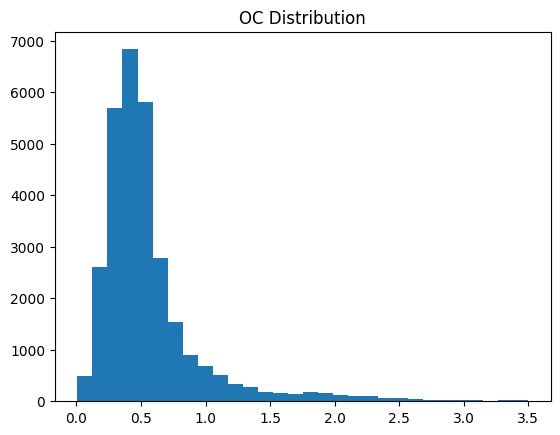

In [106]:
plt.hist(df['OC_group_median'],bins=30)
plt.title("OC Distribution")
plt.show()

In [107]:
corr_target = df.corr(numeric_only=True)['OC_numeric']
print(corr_target.sort_values(ascending=False).head(20))

OC_numeric         1.000000
OC_group_median    1.000000
OC                 1.000000
OC_group_min       0.997606
OC_group_max       0.997386
OC_log1p           0.980952
R_factor           0.497286
annual_rain_mm     0.497286
N                  0.246732
MSI                0.211066
NDBI_calc          0.203227
NDSI_SWIR_NIR      0.203227
NDBI               0.203227
Fe                 0.195481
BSI                0.169754
BSI_soil           0.169754
BI_SWIR            0.169356
B11                0.168158
B12                0.167124
NDSI_SWIR2_NIR     0.166810
Name: OC_numeric, dtype: float64


In [108]:
print(corr_target.sort_values().head(20))

elev_min_90m           -0.239471
elevation              -0.237297
elev_mean_90m          -0.237239
lon_key                -0.235057
longitude              -0.235057
elev_max_90m           -0.234458
CLIMATE_VALUE          -0.229912
NDMI2                  -0.204071
NDMI                   -0.203227
MNDWI_Green_SWIR1      -0.183490
lat_key                -0.154419
latitude               -0.154419
TPI_600m               -0.088271
NDWI_Green_NIR         -0.084192
NDWI                   -0.084150
OC_group_nunique       -0.082939
duplicate_group_size   -0.074270
TWI                    -0.067604
OC_group_range         -0.062134
TPI_300m               -0.061688
Name: OC_numeric, dtype: float64


Spatial Distribution

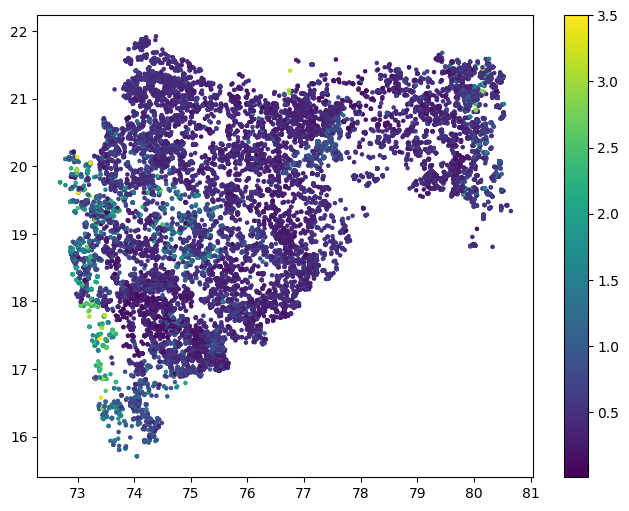

In [109]:
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'],df['latitude'],c=df['OC_numeric'],s=5)
plt.colorbar()
plt.show()

#### Heatmaps

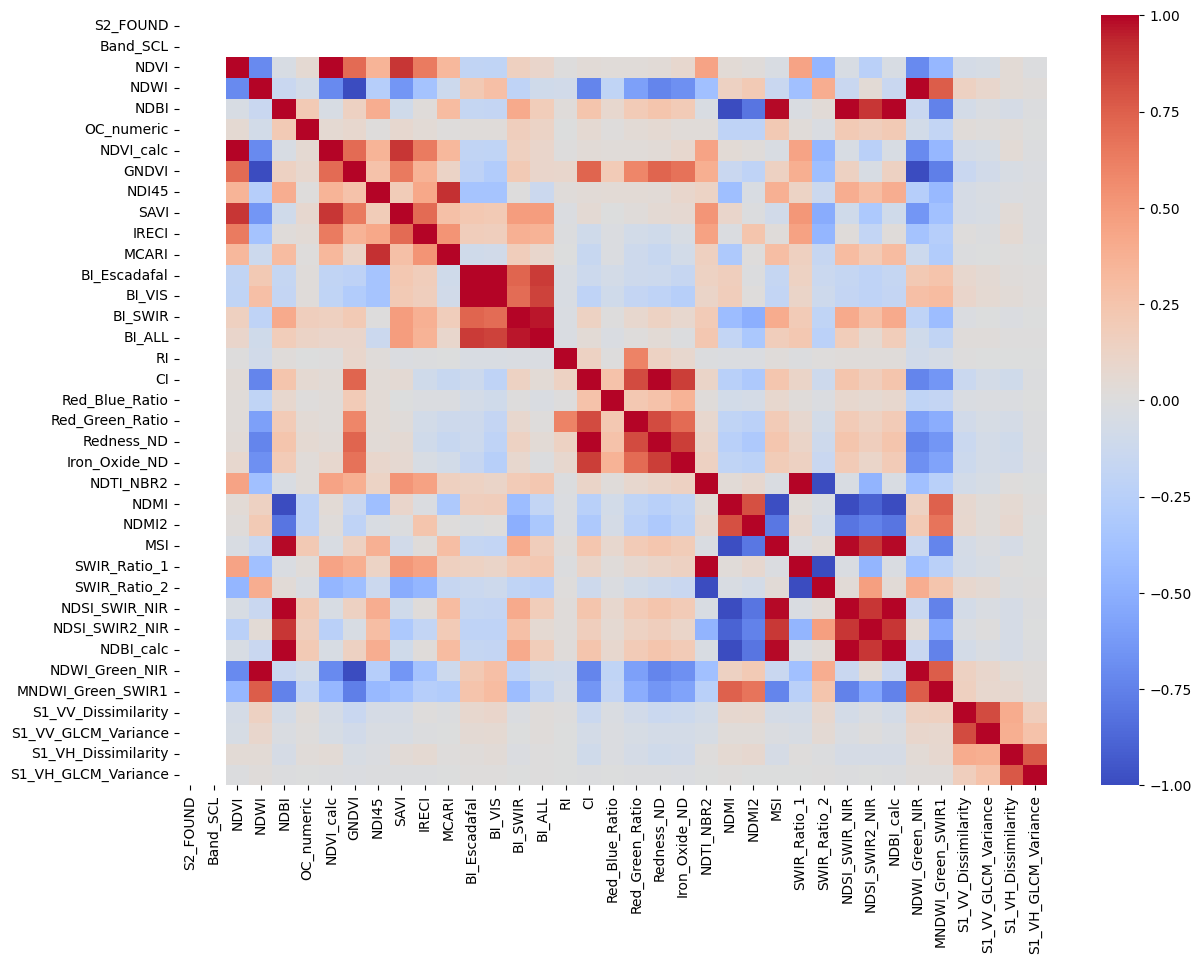

In [110]:
spectral_numeric = df[spectral_cols].select_dtypes(
    include=['float64','int64']
)

plt.figure(figsize=(14,10))

sns.heatmap(
    spectral_numeric.corr(),
    cmap='coolwarm'
)

plt.show()

Remove duplicate columns

In [111]:
oc_group_drop = [
    'OC_group_min',
    'OC_group_max',
    'OC_group_std',
    'OC_group_nunique',
    'OC_group_range',
    'duplicate_OC_conflict_class'
    'OC',
    'OC_numeric',
    'OC_bin'
]

df.drop(columns=oc_group_drop,inplace=True,errors='ignore')

In [112]:
duplicate_cols = []

for i in range(len(df.columns)):
    
    for j in range(i+1, len(df.columns)):
        
        if df.iloc[:,i].equals(
            df.iloc[:,j]
        ):
            duplicate_cols.append(
                df.columns[j]
            )

print(duplicate_cols)

['latitude', 'longitude', 'sample_date', 'OC_group_median', 'BSI_soil', 'valid_s2_for_filtering', 'bare_soil_strict', 'bare_soil_moderate', 'bare_soil_relaxed_sensitivity', 'bare_soil_strict', 'bare_soil_moderate', 'bare_soil_relaxed_sensitivity', 'bare_soil_moderate', 'bare_soil_relaxed_sensitivity', 'bare_soil_relaxed_sensitivity', 'major_road_review_zone', 'medium_road_reject', 'medium_road_review_zone', 'local_road_review_zone', 'track_road_review_zone', 'water_reject', 'water_review_zone', 'osm_any_hard_exclusion', 'osm_any_review_zone', 'building_reject', 'building_review_zone', 'developed_reject', 'developed_review_zone', 'water_polygon_reject', 'water_polygon_review_zone', 'osm_polygon_hard_exclusion', 'osm_polygon_review_zone', 'medium_road_reject', 'medium_road_review_zone', 'local_road_review_zone', 'track_road_review_zone', 'water_reject', 'water_review_zone', 'osm_any_hard_exclusion', 'osm_any_review_zone', 'building_reject', 'building_review_zone', 'developed_reject', 'de

In [113]:
for dup in duplicate_cols:
    
    for col in df.columns:
        
        if dup != col and df[dup].equals(df[col]):
            
            print(f"{dup}  <-- duplicate of -->  {col}")
            
            break

latitude  <-- duplicate of -->  lat_key
longitude  <-- duplicate of -->  lon_key
sample_date  <-- duplicate of -->  sample_date_clean
OC_group_median  <-- duplicate of -->  OC
BSI_soil  <-- duplicate of -->  BSI
valid_s2_for_filtering  <-- duplicate of -->  bare_soil_candidate
bare_soil_strict  <-- duplicate of -->  bare_soil_candidate
bare_soil_moderate  <-- duplicate of -->  bare_soil_candidate
bare_soil_relaxed_sensitivity  <-- duplicate of -->  bare_soil_candidate
bare_soil_strict  <-- duplicate of -->  bare_soil_candidate
bare_soil_moderate  <-- duplicate of -->  bare_soil_candidate
bare_soil_relaxed_sensitivity  <-- duplicate of -->  bare_soil_candidate
bare_soil_moderate  <-- duplicate of -->  bare_soil_candidate
bare_soil_relaxed_sensitivity  <-- duplicate of -->  bare_soil_candidate
bare_soil_relaxed_sensitivity  <-- duplicate of -->  bare_soil_candidate
major_road_review_zone  <-- duplicate of -->  major_road_reject
medium_road_reject  <-- duplicate of -->  major_road_reject


In [114]:
drop_dup = [
    'sample_date',          # keep sample_date_clean
    'lat_key',              # keep latitude
    'lon_key',              # keep longitude
    'BSI_soil',             # duplicate of BSI
    'Redness_ND',           # duplicate of CI
    'NDBI_calc'             # duplicate of NDSI_SWIR_NIR
]
df.drop(
    columns=drop_dup,inplace=True,errors='ignore')

In [115]:
df.drop(columns=[
        'id',
        'row_id',
        'computedID',
        'surveyNo'
    ], inplace=True,
    errors='ignore'
)

In [116]:
df['sample_date_clean'] = pd.to_datetime(
    df['sample_date_clean'],
    format='%d-%m-%Y'
)

In [117]:
df['year'] = df['sample_date_clean'].dt.year

df['month'] = df['sample_date_clean'].dt.month

df['dayofyear'] = df['sample_date_clean'].dt.dayofyear
df.drop(
    columns=['sample_date_clean'],
    inplace=True
)

/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_3075/2495660482.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year'] = df['sample_date_clean'].dt.year
/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_3075/2495660482.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month'] = df['sample_date_clean'].dt.month
/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_3075/2495660482.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

In [118]:
print(df.head())

       fid   latitude  longitude  CLIMATE_VALUE CLIMATE_SUBCLASS  \
0  48980.0  15.709677  74.047631            2.0               Am   
1  48981.0  15.709731  74.048897            2.0               Am   
2  48982.0  15.711065  74.047657            2.0               Am   
3  48839.5  15.804995  73.733783            2.0               Am   
4  48835.0  15.805012  73.734112            2.0               Am   

  CLIMATE_CLASS DOMSOI SOIL_TYPE      SOIL_SUBCLASS  elevation  ...  \
0      Tropical     Ap  ACRISOLS  Plinthic Acrisols       55.0  ...   
1      Tropical     Ap  ACRISOLS  Plinthic Acrisols       55.0  ...   
2      Tropical     Ap  ACRISOLS  Plinthic Acrisols       51.0  ...   
3      Tropical     Nd  NITOSOLS   Dystric Nitosols       19.0  ...   
4      Tropical     Nd  NITOSOLS   Dystric Nitosols       19.0  ...   

   S1_VH_ASM  S1_VH_Energy  S1_VH_MaxProbability  S1_VH_Entropy  \
0   0.699068      0.999988              0.995973      -4.731746   
1   0.636399      0.999990    

In [119]:
df.to_csv("cleaned_MH_OC.csv",index=False)